In [ ]:
from methylseqnet.dataset import BaseHDF5Dataset
from methylseqnet.peaks import selected_peaks_from_target
from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import torch
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from collections import defaultdict
import pysam
from methylseqnet_repro.paths import configs, atac_atlas, methylation_atlas, preprocessed_datasets
from mpl_toolkits.axes_grid1 import make_axes_locatable
from adjustText import adjust_text
import re

In [2]:
methylation_parent_folder = methylation_atlas
atlas_folder = preprocessed_datasets / "atlas"
longread_folder = preprocessed_datasets / "gm12878_haplotyped"
def rowwise_corrcoef(X, y):
    # Center
    X_c = X - X.mean(axis=1, keepdims=True)
    y_c = y - y.mean()
    # Correlations
    num = X_c @ y_c
    denom = np.sqrt((X_c**2).sum(axis=1) * (y_c**2).sum())
    return num / denom

  0%|          | 0/6888 [00:00<?, ?it/s]

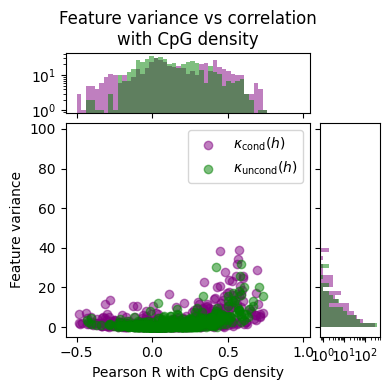

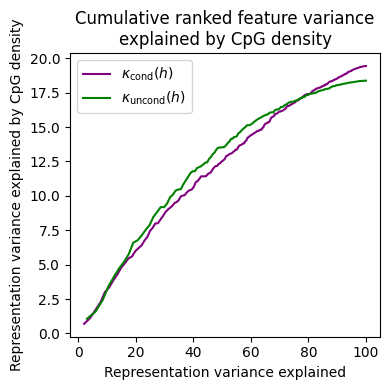

  0%|          | 0/6888 [00:00<?, ?it/s]

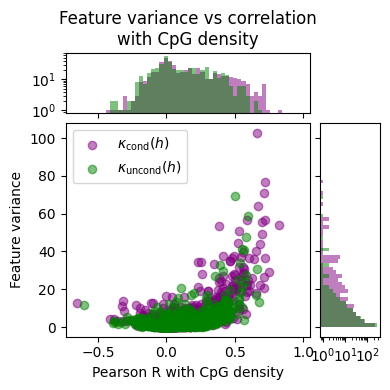

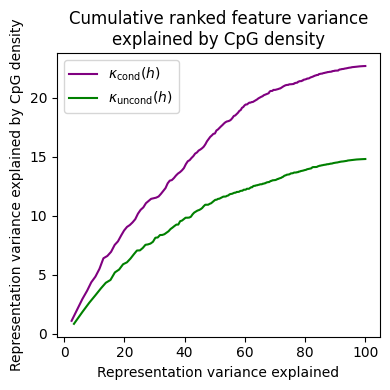

  0%|          | 0/6888 [00:00<?, ?it/s]

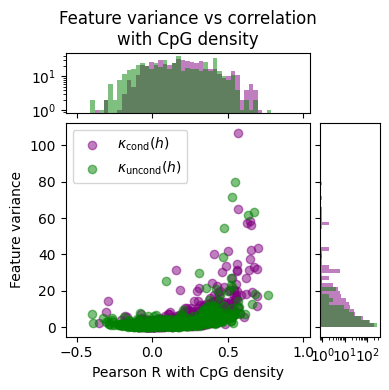

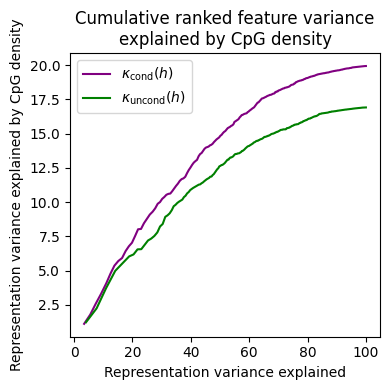

  0%|          | 0/6888 [00:00<?, ?it/s]

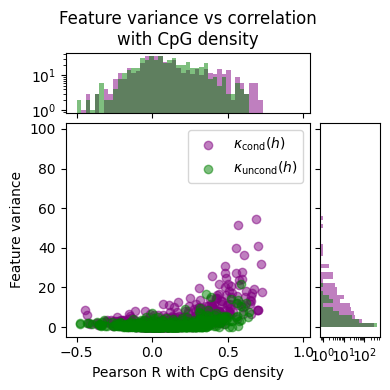

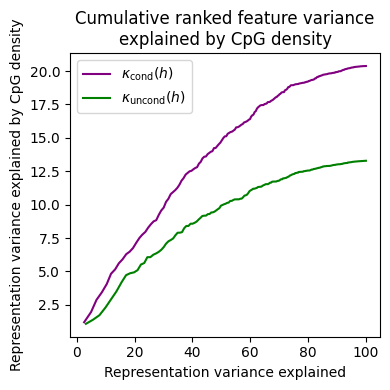

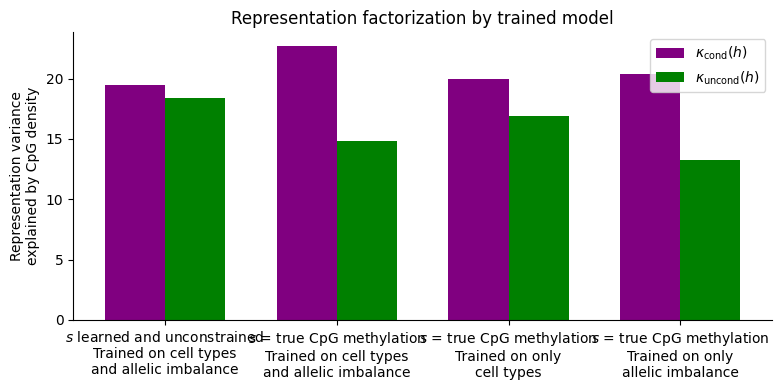

In [ ]:
from matplotlib import colors

prediction_datasets_dict = {
    r'$s$ learned and unconstrained'+'\nTrained on cell types\nand allelic imbalance':(
        atlas_folder / "slurm32603230task36" / "fold3" / "predictions.h5",
        "supplement__joint_trained",
    ),
    r'$s$ = true CpG methylation'+'\nTrained on cell types\nand allelic imbalance':(
        atlas_folder / "slurm32260895task0" / "fold3_truecondweight_1.0" / "predictions.h5",
        "overview__joint_trained",
    ),
    r'$s$ = true CpG methylation'+'\nTrained on only\ncell types':(
        atlas_folder / "slurm32260895task8" / "fold3" / "predictions.h5",
        "supplement__cell_types_only",
    ),
    r'$s$ = true CpG methylation'+'\nTrained on only\nallelic imbalance':(
        longread_folder / "slurm32265241task31" / "fold3" / "predictions.h5",
        "supplement__allelic_imbalance_only",
    ),
}

conditional_variance_explained_dict = {}
unconditional_variance_explained_dict = {}

fold = 3
bin_size = 128
activations_threshold = 1
figsize = (4,4)

def collate_fn(batch):
    # Separate your data into different types
    collated_batch = {}
    for key, value in batch[0].items():
        if isinstance(value, str): 
            collated_batch[key] = [item[key] for item in batch]
        elif isinstance(value, torch.Tensor):
            collated_batch[key] = torch.stack([item[key] for item in batch])
        elif isinstance(value, np.ndarray):
            collated_batch[key] = np.stack([item[key] for item in batch])
        else:
            raise TypeError(f"Unsupported data type for key {key}: {type(value)}")
    return collated_batch
max_samples = None
active_sites = None
active_site_threshold = 15

for model_description, (dataset_path, file_description) in prediction_datasets_dict.items():
    if active_sites is None:
        datasets_to_load = {'tracks','cpg_density','conditional_seq_rep','unconditional_seq_rep'}
    else:
        datasets_to_load = {'cpg_density','conditional_seq_rep','unconditional_seq_rep'}

    dataset = BaseHDF5Dataset(dataset_path,datasets=datasets_to_load,return_specifiers=True)
    io_mappings_df = dataset.get_io_mappings_df()
    atac_channels = io_mappings_df[io_mappings_df['data_type']=='ATAC-seq']['channel'].tolist()
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

    cpg_density_list = []
    targets_list = []
    conditional_seq_rep_list = []
    unconditional_seq_rep_list = []

    for idx, sample in tqdm(enumerate(dataloader),total=max_samples if max_samples is not None else len(dataloader)):
        if max_samples is not None and idx >= max_samples:
            break
        cpg_density_list.append(sample['cpg_density'].squeeze().numpy())
        if 'tracks' in sample:
            targets_list.append(sample['tracks'].squeeze().numpy())
        conditional_seq_rep_list.append(sample['conditional_seq_rep'].squeeze().numpy())
        unconditional_seq_rep_list.append(sample['unconditional_seq_rep'].squeeze().numpy())

    all_cpg_densities = np.concatenate(cpg_density_list, axis=0)
    all_conditional_seq_reps = np.concatenate(conditional_seq_rep_list, axis=1)
    all_unconditional_seq_reps = np.concatenate(unconditional_seq_rep_list, axis=1)

    if active_sites is None:
        if len(atac_channels) > 0 and len(targets_list) > 0:
            all_targets = np.concatenate(targets_list, axis=1)
            # active_sites = selected_peaks_from_target(
            #     target = all_targets[atac_channels,:].max(axis=0),
            #     peak_threshold = active_site_threshold,
            #     min_peak_distance_bins = 8,
            # )
            active_sites = np.where(all_targets[atac_channels,:].max(axis=0) > active_site_threshold)[0]
        else:
            raise ValueError("The first dataset must be from a model with ATAC-seq tasks to determine active sites. No ATAC-seq channels found in the first dataset.")

    mean_unconditional_activations = all_unconditional_seq_reps.mean(axis=0)
    mean_conditional_activations = all_conditional_seq_reps.mean(axis=0)

    # reps_fig, reps_axs = plt.subplots(2,2, figsize=(8,8))
    # reps_fig.suptitle(f"Embedding feature analysis at active sites\n{model_description}")
    conditional_correlations = rowwise_corrcoef(all_conditional_seq_reps[:,active_sites], all_cpg_densities[active_sites])
    unconditional_correlations = rowwise_corrcoef(all_unconditional_seq_reps[:,active_sites], all_cpg_densities[active_sites])
    conditional_means = all_conditional_seq_reps[:,active_sites].mean(axis=1)
    unconditional_means = all_unconditional_seq_reps[:,active_sites].mean(axis=1)
    conditional_variances = all_conditional_seq_reps[:,active_sites].var(axis=1)
    unconditional_variances = all_unconditional_seq_reps[:,active_sites].var(axis=1)
    conditional_fve = (np.abs(conditional_correlations) * conditional_variances).sum() / conditional_variances.sum()
    # unconditional_fve = (np.abs(unconditional_correlations) * unconditional_variances).sum() / unconditional_variances.sum()
    # reps_axs[0,0].hist(np.abs(conditional_correlations), bins=50, alpha=0.5, label=r'$\kappa_{\mathrm{cond}}(h)$' + f'\nmean: {np.nanmean(np.abs(conditional_correlations)):.3f}')
    # reps_axs[0,0].hist(np.abs(unconditional_correlations), bins=50, alpha=0.5, label=r'$\kappa_{\mathrm{cond}}(h)$' + f'\nmean: {np.nanmean(np.abs(unconditional_correlations)):.3f}')
    # reps_axs[0,0].legend()
    # reps_axs[0,0].set_title("Embeddings activations across active sites\ncorrelation with CpG density")
    # reps_axs[0,0].set_xlabel('abs(correlation with CpG density)')
    # reps_axs[0,0].set_ylabel('count')
    # reps_axs[0,1].hist(mean_unconditional_activations, bins=50, color='green', alpha=0.5, label=r'$\kappa_{\mathrm{cond}}(h)$' + f'\nmean: {np.nanmean(mean_unconditional_activations):.3f}')
    # reps_axs[0,1].hist(mean_conditional_activations, bins=50, color='purple', alpha=0.5, label=r'$\kappa_{\mathrm{cond}}(h)$' + f'\nmean: {np.nanmean(mean_conditional_activations):.3f}')
    # reps_axs[0,1].axvline(activations_threshold, color='red', linestyle='--', label=f'active site threshold\n{activations_threshold}')
    # reps_axs[0,1].legend()
    # reps_axs[0,1].set_title("Mean embedding activation across active sites")
    # reps_axs[0,1].semilogy()
    # reps_axs[1,0].scatter(conditional_correlations,conditional_variances, color='purple', alpha=0.5, label=r'$\kappa_{\mathrm{cond}}(h)$') #rep\nmean: {np.nanmean(conditional_variances):.3f}
    # reps_axs[1,0].scatter(unconditional_correlations,unconditional_variances, color='green', alpha=0.5, label=r'$\kappa_{\mathrm{uncond}}(h)$') # rep\nmean: {np.nanmean(unconditional_variances):.3f}'
    # reps_axs[1,0].legend()
    # reps_axs[1,0].legend()
    # reps_axs[1,0].set_xlabel('Pearson R with CpG density\nacross test set active sites')
    # reps_axs[1,0].set_ylabel('feature variance\nacross test set active sites')
    # ax = reps_axs[1,0]  # your scatter panel
    # divider = make_axes_locatable(ax)
    # ax_histx = divider.append_axes("top", 0.6, pad=0.1, sharex=ax)
    # ax_histy = divider.append_axes("right", 0.6, pad=0.1, sharey=ax)
    # ax_histx.tick_params(labelbottom=False)
    # ax_histy.tick_params(labelleft=False)
    # ax_histx.set_yscale('log')
    # ax_histy.set_xscale('log')
    # ax_histx.set_title("Feature variance vs correlation\nwith CpG density")

    # ax_histx.hist(conditional_correlations, bins=np.arange(-0.5,1,0.03), alpha=0.5, color='purple')
    # ax_histx.hist(unconditional_correlations, bins=np.arange(-0.5,1,0.03), alpha=0.5, color='green')
    # ax_histy.hist(conditional_variances, bins=np.arange(0,100,2), alpha=0.5, color='purple', orientation='horizontal')
    # ax_histy.hist(unconditional_variances, bins=np.arange(0,100,2), alpha=0.5, color='green', orientation='horizontal')

    # Conditional
    cond_order = np.argsort(conditional_variances)[::-1]
    cond_cumvar_frac = np.cumsum(conditional_variances[cond_order]) / conditional_variances.sum() * 100
    cond_cum_explained = np.cumsum((conditional_correlations[cond_order]**2 * conditional_variances[cond_order])) / conditional_variances.sum() * 100

    # Unconditional
    uncond_order = np.argsort(unconditional_variances)[::-1]
    uncond_cumvar_frac = np.cumsum(unconditional_variances[uncond_order]) / unconditional_variances.sum() * 100
    uncond_cum_explained = np.cumsum((unconditional_correlations[uncond_order]**2 * unconditional_variances[uncond_order])) / unconditional_variances.sum() * 100

    # ax = reps_axs[1,1]
    # ax.plot(cond_cumvar_frac, cond_cum_explained, color='purple', label=r'$\kappa_{\mathrm{cond}}(h)$')
    # ax.plot(uncond_cumvar_frac, uncond_cum_explained, color='green', label=r'$\kappa_{\mathrm{uncond}}(h)$')
    # ax.set_xlabel('% total embedding variance explained\nby top N features (ranked by variance)')
    # ax.set_ylabel('% total variance explained\nby CpG density')
    # ax.set_title('Cumulative ranked feature variance\nexplained by CpG density')

    cond_total_explained = (conditional_correlations**2 * conditional_variances).sum() / conditional_variances.sum() * 100
    uncond_total_explained = (unconditional_correlations**2 * unconditional_variances).sum() / unconditional_variances.sum() * 100

    conditional_variance_explained_dict[model_description] = cond_total_explained
    unconditional_variance_explained_dict[model_description] = uncond_total_explained

    # ax.legend()
    # reps_fig.tight_layout()
    # plt.show()

    # Bottom-left: Feature variance vs correlation with CpG density (with marginal histograms)
    fig1, ax1 = plt.subplots(figsize=figsize)
    ax1.scatter(conditional_correlations, conditional_variances, color='purple', alpha=0.5, label=r'$\kappa_{\mathrm{cond}}(h)$')
    ax1.scatter(unconditional_correlations, unconditional_variances, color='green', alpha=0.5, label=r'$\kappa_{\mathrm{uncond}}(h)$')
    ax1.legend()
    ax1.set_xlabel('Pearson R with CpG density')
    ax1.set_ylabel('Feature variance')

    divider = make_axes_locatable(ax1)
    ax_histx = divider.append_axes("top", 0.6, pad=0.1, sharex=ax1)
    ax_histy = divider.append_axes("right", 0.6, pad=0.1, sharey=ax1)
    ax_histx.tick_params(labelbottom=False)
    ax_histy.tick_params(labelleft=False)
    ax_histx.set_yscale('log')
    ax_histy.set_xscale('log')
    ax_histx.set_title("Feature variance vs correlation\nwith CpG density")
    ax_histx.hist(conditional_correlations, bins=np.arange(-0.5, 1, 0.03), alpha=0.5, color='purple')
    ax_histx.hist(unconditional_correlations, bins=np.arange(-0.5, 1, 0.03), alpha=0.5, color='green')
    ax_histy.hist(conditional_variances, bins=np.arange(0, 100, 2), alpha=0.5, color='purple', orientation='horizontal')
    ax_histy.hist(unconditional_variances, bins=np.arange(0, 100, 2), alpha=0.5, color='green', orientation='horizontal')

    fig1.tight_layout()
    fig1.savefig(f"pdfs/{file_description}_feature_variance_vs_cpg_correlation.pdf", bbox_inches='tight')
    plt.show()

    # Bottom-right: Cumulative ranked feature variance explained by CpG density
    fig2, ax2 = plt.subplots(figsize=figsize)
    ax2.plot(cond_cumvar_frac, cond_cum_explained, color='purple', label=r'$\kappa_{\mathrm{cond}}(h)$')
    ax2.plot(uncond_cumvar_frac, uncond_cum_explained, color='green', label=r'$\kappa_{\mathrm{uncond}}(h)$')
    ax2.set_xlabel('Representation variance explained')
    ax2.set_ylabel('Representation variance explained by CpG density')
    ax2.set_title('Cumulative ranked feature variance\nexplained by CpG density')
    ax2.legend()

    fig2.tight_layout()
    fig2.savefig(f"pdfs/{file_description}_cumulative_variance_explained_by_cpg.pdf", bbox_inches='tight')
    plt.show()

keys = list(conditional_variance_explained_dict.keys())
cond_vals = [conditional_variance_explained_dict[k] for k in keys]
uncond_vals = [unconditional_variance_explained_dict[k] for k in keys]

x = np.arange(len(keys))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.set_title("Representation factorization by trained model")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.bar(x - width/2, cond_vals, width, label=r'$\kappa_{\mathrm{cond}}(h)$', color='purple')
ax.bar(x + width/2, uncond_vals, width, label=r'$\kappa_{\mathrm{uncond}}(h)$', color='green')
ax.set_xticks(x)
ax.set_xticklabels(keys, rotation=0, ha='center', fontsize=9)
ax.set_ylabel('Representation variance\nexplained by CpG density')
ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig(f"pdfs/supplement__variance_explained_by_cpg_density.pdf", bbox_inches='tight')
fig.show()

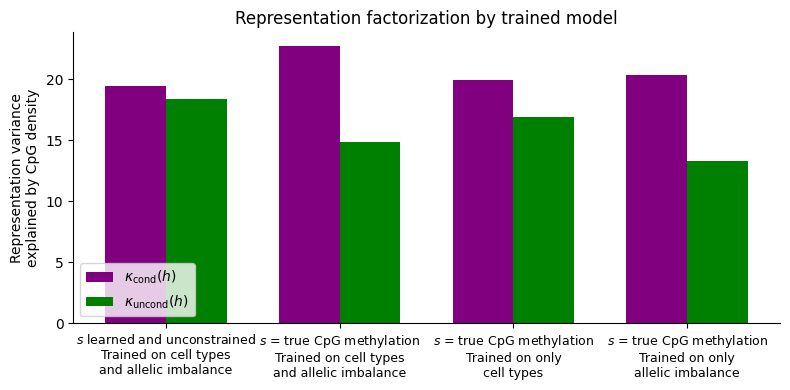